# Predicción de victorias/derrotas con métricas ROLL10

En este cuaderno construiremos un flujo completo y fácilmente extensible para predecir si el equipo local ganará o perderá un partido (`W/L`). El objetivo es mantener un **pipeline didáctico**, apoyándonos en las métricas rodantes de los últimos 10 encuentros (`ROLL10_…`) y transformándolas a un **dataset a nivel de partido (home vs away)** con características relativas.

Los pasos principales incluyen: (1) recalcular las medias rodantes sin fuga temporal mediante `shift(1)`, (2) generar el dataset home/away con variables diferenciales entre ambos equipos y (3) entrenar un modelo **XGBoost** con *early stopping*. Además, seleccionaremos el umbral óptimo en validación con el criterio de **Youden**, representaremos las métricas clave y exportaremos las predicciones para su análisis posterior.

En esta versión extendida incorporamos señales avanzadas de **momentum, descanso y eficiencia reciente** (rachas, % en los últimos 5 partidos, días de descanso, ritmo y turnovers) y comparamos tres configuraciones de modelo: Baseline, Venue+ y Enhanced.


In [34]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

try:
    from xgboost import XGBClassifier
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')



In [35]:
import importlib.util, sys
spec = importlib.util.spec_from_file_location("feature_functions", "02_FeatureFunctions.py")
feature_functions = importlib.util.module_from_spec(spec)
sys.modules["feature_functions"] = feature_functions
spec.loader.exec_module(feature_functions)
from feature_functions import *



## Configuración principal

La celda siguiente concentra todas las opciones importantes del flujo: rutas de entrada/salida, ventana rolling, lista de métricas base y parámetros de muestreo. Modificando este bloque se pueden probar nuevas combinaciones de características, activar fuentes externas o ajustar la semilla de aleatoriedad.



In [36]:
# === CONFIGURACIÓN PRINCIPAL ===

DATA_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet"
FEATURIZED_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/2024-25/teamgamelogs_featurized.parquet"
OUTPUT_DIR = "/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds"
ROLLING_WINDOW = 10
BASE_FEATURES = [
    'NET_RATING','E_NET_RATING','DEF_RATING','E_DEF_RATING',
    'PTS','FGM','FG_PCT','EFG_PCT','TS_PCT',
    'TOV','TM_TOV_PCT','OREB_PCT','DREB','POSS',
    'PACE','PCT_FGA_2PT','PCT_FGA_3PT','PCT_PTS_FT'
]
RELATIVE_PREFIXES = ("ROLL10_",)
TEST_SIZE = 0.20
VAL_SIZE = 0.10
RANDOM_STATE = 42

# === CONFIGURACIÓN AMPLIADA ===
NEW_FEATURES_CONFIG = {
    'days_rest_path': "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_dashboard_by_general_splits__dataset_5.parquet",
    'new_features': [
        'WIN_STREAK', 'LAST_5_PCT', 'DAYS_REST', 'SEASON_W_PCT',
        'PACE', 'TURNOVER_RATIO'
    ]
}

# === OPCIONAL: Parquets externos ===
# ExternalFeaturesConfig = [
#     {
#         "path": "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/dashboards/team_dash_pt_pass__dataset_0.parquet",
#         "on": ["TEAM_ID","GAME_DATE"],
#         "select": ["AST_PCT","PCT_AST_2PM","PCT_AST_3PM"],
#         "prefix": "PASS_"
#     }
# ]
ExternalFeaturesConfig = []



## Carga y limpieza de datos

Cargamos el parquet indicado en la configuración y nos aseguramos de que las columnas fundamentales estén presentes. Convertimos `GAME_DATE` a formato `datetime`, generamos `WL_NUM` si solo contamos con la etiqueta textual y dejamos únicamente identificadores más las métricas base que alimentarán el cálculo rolling y las diferencias home/away.



In [37]:
df = pd.read_parquet(DATA_PATH)
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

# Asegura columna binaria del resultado
if 'WL_NUM' not in df.columns and 'WL' in df.columns:
    df['WL_NUM'] = df['WL'].map({'W': 1, 'L': 0})
elif 'WL' not in df.columns and 'WL_NUM' in df.columns:
    df['WL'] = df['WL_NUM'].map({1: 'W', 0: 'L'})

print(f"Filas totales iniciales: {len(df)}")
print(f"Rango de fechas: {df['GAME_DATE'].min().date()} → {df['GAME_DATE'].max().date()}")
print(f"Equipos únicos: {df['TEAM_ID'].nunique()}")
df.head(3)


Filas totales iniciales: 2639
Rango de fechas: 2024-07-06 → 2025-04-13
Equipos únicos: 30


,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,ROLL10_PCT_PTS_OFF_TOV,ROLL10_PCT_PTS_PAINT,ROLL10_PCT_REB,ROLL10_PCT_STL,ROLL10_PCT_TOV,ROLL10_PCT_UAST_2PM,ROLL10_PCT_UAST_3PM,ROLL10_PCT_UAST_FGM,ROLL10_PLUS_MINUS,WL_NUM
0,2024-25,1610612737,ATL,Atlanta Hawks,0022400001,2024-11-12,ATL @ BOS,W,48.0,50,...,0.165379,0.469989,0.189148,0.173559,0.178534,0.279724,0.092822,0.241912,-6.5,1
1,2024-25,1610612738,BOS,Boston Celtics,0022400001,2024-11-12,BOS vs. ATL,L,48.0,38,...,0.111191,0.318844,0.199744,0.182397,0.169099,0.386928,0.121711,0.302243,9.3,0
2,2024-25,1610612748,MIA,Miami Heat,0022400002,2024-11-12,MIA @ DET,L,53.0,47,...,0.163480,0.379894,0.207982,0.161598,0.168327,0.301137,0.077169,0.263276,-0.6,0



## Enriquecimiento de features mediante funciones modulares

Aplicamos secuencialmente las funciones utilitarias importadas desde `FeatureFunctions.py` para preparar las métricas rolling, el momentum/descanso y los splits por sede.



In [38]:
df = features_roll10(df)

df.head(3)


Columnas ROLL10 detectadas: 75
Filas totales tras selección: 2639
Rango de fechas tras selección: 2024-07-06 → 2025-04-13
Equipos únicos tras selección: 30
Columnas ROLL10 imputadas (mediana): 75


,TEAM_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,MATCHUP,WL,WL_NUM,ROLL10_AST,ROLL10_AST_PCT,ROLL10_AST_TOV,...,ROLL10_PTS_FB,ROLL10_PTS_OFF_TOV,ROLL10_PTS_PAINT,ROLL10_REB,ROLL10_REB_PCT,ROLL10_STL,ROLL10_TM_TOV_PCT,ROLL10_TOV,ROLL10_TS_PCT,ROLL10_USG_PCT
2485,1610612737,ATL,1522400006,2024-07-12,ATL @ WAS,L,0,25.9,0.149213,1.16282,...,1.461793,1.664954,4.621433,43.6,0.088065,8.1,9.821217,14.4,0.535424,0.182748
2515,1610612737,ATL,1522400021,2024-07-14,ATL vs. SAS,L,0,14.0,0.149213,1.16282,...,1.461793,1.664954,4.621433,41.0,0.088065,10.0,9.821217,15.0,0.535424,0.182748
2561,1610612737,ATL,1522400044,2024-07-17,ATL vs. LAL,L,0,15.0,0.149213,1.16282,...,1.461793,1.664954,4.621433,41.5,0.088065,9.5,9.821217,16.0,0.535424,0.182748


In [39]:
df = features_enhanced(df, NEW_FEATURES_CONFIG)
available_advanced = [feat for feat in NEW_FEATURES_CONFIG['new_features'] if feat in df.columns]
print(f"Features avanzadas generadas: {available_advanced}")
df.head(3)[['TEAM_ABBREVIATION', 'GAME_DATE'] + available_advanced[:4]]


⚠️ El parquet de days rest no contiene TEAM_ID y/o GAME_DATE. Se omite.
⚠️ No se aplicó referencia externa de Days Rest (archivo vacío o inválido).
Features avanzadas generadas: ['WIN_STREAK', 'LAST_5_PCT', 'DAYS_REST', 'SEASON_W_PCT', 'PACE', 'TURNOVER_RATIO']


,TEAM_ABBREVIATION,GAME_DATE,WIN_STREAK,LAST_5_PCT,DAYS_REST,SEASON_W_PCT
0,ATL,2024-07-12,0,0.5,5,0.5
1,ATL,2024-07-14,0,0.0,2,0.0
2,ATL,2024-07-17,0,0.0,3,0.0



## Añadir features externas (opcional)

Si deseamos enriquecer el dataset con variables adicionales, podemos utilizar la estructura `ExternalFeaturesConfig`. Cada elemento define la ruta del parquet, las claves de unión, las columnas que queremos incorporar y un prefijo para renombrarlas. El siguiente ejemplo permanece comentado para mantener el flujo base ligero, pero sirve como plantilla para añadir más información cuando sea necesario.



In [40]:

# def add_external_features(df, cfg):
#     ext = pd.read_parquet(cfg["path"])
#     ext = ext[cfg["on"] + cfg["select"]]
#     new_cols = [cfg["prefix"] + c for c in cfg["select"]]
#     ext.columns = cfg["on"] + new_cols
#     return df.merge(ext, on=cfg["on"], how="left")

# for cfg in ExternalFeaturesConfig:
#     df = add_external_features(df, cfg)
# print("Datos extendidos con features externas (si las hubiera).")




## Cálculo de métricas rolling sin fuga

La función `features_roll10()` ordena por equipo y fecha, utiliza `shift(1)` en el parquet featurizado y aplica las medianas móviles precomputadas, asegurando que cada fila solo considere información anterior al partido en cuestión.




## Imputación de valores nulos

`features_roll10()` también cubre la imputación de valores faltantes rellenando con la mediana de cada métrica rolling para evitar fugas o discontinuidades en la construcción de diferencias home/away.




## Construcción del dataset local vs visitante

La función `build_match_dataset_enhanced()` transforma el registro por equipo en un dataset a nivel de partido. Identifica al local mediante `MATCHUP`, cruza locales y visitantes por `GAME_ID` y genera características diferenciales (`HOME_x - AWAY_x`) manteniendo el objetivo (`y`) desde la perspectiva local.



# 🏟️ Features externas: Splits por sede (Home/Road)

Para evaluar el impacto de jugar en casa o fuera añadiremos los splits de victorias por sede provenientes de los dashboards oficiales:

- Cargamos el parquet `team_dashboard_by_general_splits` desde la carpeta de dashboards.
- Filtramos el bloque `Location` y pivotamos para obtener `VENUE_HOME_W_PCT` y `VENUE_ROAD_W_PCT` por equipo y temporada.
- Si el dataset no trae la temporada explícita, la inferimos a partir de la fecha (`season` NBA comienza en agosto).
- Fusionamos los splits con el `DataFrame` principal y rellenamos nulos con la mediana para evitar fugas accidentales.
- Nota de seguridad: son métricas agregadas por equipo-temporada, por lo que no anticipan resultados futuros de un partido concreto.


In [41]:
df = features_venue(df)

df[[c for c in df.columns if c.startswith('VENUE_')]].head(3)


OK: Splits por sede añadidos desde 'team_dashboard_by_general_splits__dataset_1.parquet'
Shape: (2639, 92) -> (2639, 93) (merge left; columnas añadidas al final)
Columnas nuevas presentes: ['VENUE_HOME_W_PCT', 'VENUE_ROAD_W_PCT']
Imputaciones aplicadas: {'VENUE_HOME_W_PCT': 0.535, 'VENUE_ROAD_W_PCT': 0.467}


,VENUE_HOME_W_PCT,VENUE_ROAD_W_PCT
0,0.488,0.442
1,0.488,0.442
2,0.488,0.442


# ⚡ Dataset de Partidos con Features Avanzadas

Construimos el dataset a nivel partido combinando local vs. visitante y generando diferencias relativas tanto de las métricas `ROLL10_` como de las nuevas señales de momentum, descanso y eficiencia. Mantenemos el indicador `HOME_COURT` y añadimos `B2B_ADVANTAGE` para capturar escenarios de back-to-back.


In [42]:
df.to_parquet(FEATURIZED_PATH)
print(f"Dataset featurizado guardado en: {FEATURIZED_PATH}")


Dataset featurizado guardado en: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/2024-25/teamgamelogs_featurized.parquet


In [43]:
X_all, y_all, meta_all = build_match_dataset_enhanced(df)
print(f"Shape X: {X_all.shape}")
print(f"Tasa de victoria local: {y_all.mean():.3f}")
X_all.head()


Shape X: (1311, 85)
Tasa de victoria local: 0.543


,DIFF_ROLL10_AST,DIFF_ROLL10_AST_PCT,DIFF_ROLL10_AST_TOV,DIFF_ROLL10_BLK,DIFF_ROLL10_BLKA,DIFF_ROLL10_DEF_RATING,DIFF_ROLL10_DREB,DIFF_ROLL10_DREB_PCT,DIFF_ROLL10_EFG_PCT,DIFF_ROLL10_E_DEF_RATING,...,DIFF_VENUE_ROAD_W_PCT,HOME_COURT,DIFF_VENUE_W_PCT,DIFF_WIN_STREAK,DIFF_LAST_5_PCT,DIFF_DAYS_REST,DIFF_SEASON_W_PCT,DIFF_PACE,DIFF_TURNOVER_RATIO,B2B_ADVANTAGE
0,-0.500000,0.00000,0.00000,3.750000,2.000000,0.00000,5.000000,0.00000,0.00000,0.00000,...,0.078,1,0.124,-3,-0.5,1,-0.500000,0.00000,-0.020621,0
1,-2.800000,0.00000,0.00000,1.200000,-0.400000,0.00000,3.500000,0.00000,0.00000,0.00000,...,-0.025,1,0.021,0,0.0,1,0.000000,0.00000,0.028870,0
2,-2.250000,0.00000,0.00000,3.250000,1.250000,0.00000,1.500000,0.00000,0.00000,0.00000,...,-0.149,1,-0.103,-3,-0.5,0,-0.500000,0.00000,0.067020,0
3,-0.600000,0.00000,0.00000,1.000000,1.600000,0.00000,4.600000,0.00000,0.00000,0.00000,...,0.093,1,0.139,0,-0.6,0,-0.600000,0.00000,0.053616,0
4,0.111111,0.02026,0.10289,-0.166667,0.833333,5.61444,-1.666667,0.00354,0.00186,5.61444,...,0.181,1,0.227,-2,-0.6,0,-0.722222,8.10956,0.016435,0


# 🏆 Comparación de modelos: Baseline vs Venue+ vs Enhanced

Evaluamos tres configuraciones crecientes para aislar el valor de las nuevas métricas de momentum y descanso frente a las referencias previas.


In [44]:
# === Preparación de datasets comparativos ===

base_features = [c for c in X_all.columns if c.startswith('DIFF_ROLL10_') or c == 'HOME_COURT']
venue_features = base_features + [c for c in ['DIFF_VENUE_W_PCT'] if c in X_all.columns]
enhanced_candidates = [
    'DIFF_WIN_STREAK', 'DIFF_LAST_5_PCT', 'DIFF_DAYS_REST',
    'DIFF_SEASON_W_PCT', 'DIFF_PACE', 'DIFF_TURNOVER_RATIO', 'B2B_ADVANTAGE'
]
enhanced_features = venue_features + [c for c in enhanced_candidates if c in X_all.columns]


def unique_preserve_order(seq):
    seen = set()
    ordered = []
    for item in seq:
        if item not in seen:
            seen.add(item)
            ordered.append(item)
    return ordered


base_features = unique_preserve_order(base_features)
venue_features = unique_preserve_order(venue_features)
enhanced_features = unique_preserve_order(enhanced_features)

X_all_base = X_all[base_features].copy()
X_all_venue = X_all[venue_features].copy()
X_all_enhanced = X_all[enhanced_features].copy()

print(f"Features Baseline: {len(base_features)}")
print(f"Features Venue+: {len(venue_features)}")
print(f"Features Enhanced: {len(enhanced_features)}")

feature_sets = {
    'Baseline': X_all_base,
    'Venue+': X_all_venue,
    'Enhanced': X_all_enhanced
}


def create_comparison_splits(feature_sets, y, meta, test_size, val_size, random_state):
    indices = np.arange(len(y))
    y_array = np.asarray(y)

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y_array
    )

    train_idx, val_idx = train_test_split(
        train_idx,
        test_size=val_size,
        random_state=random_state,
        stratify=y_array[train_idx]
    )

    def subset(data, idx):
        if isinstance(data, (pd.DataFrame, pd.Series)):
            return data.iloc[idx]
        return data[idx]

    meta_reset = meta.reset_index(drop=True)

    feature_splits = {}
    for name, X in feature_sets.items():
        feature_splits[name] = {
            'X_train': subset(X, train_idx),
            'X_val': subset(X, val_idx),
            'X_test': subset(X, test_idx),
        }

    return {
        'indices': {'train': train_idx, 'val': val_idx, 'test': test_idx},
        'features': feature_splits,
        'y': {
            'train': subset(y_array, train_idx),
            'val': subset(y_array, val_idx),
            'test': subset(y_array, test_idx),
        },
        'meta': {
            'train': subset(meta_reset, train_idx).reset_index(drop=True),
            'val': subset(meta_reset, val_idx).reset_index(drop=True),
            'test': subset(meta_reset, test_idx).reset_index(drop=True),
        }
    }


Features Baseline: 76
Features Venue+: 77
Features Enhanced: 84


## Entrenamiento con XGBoost y validación temporal

A partir de los splits generados, entrenamos dos modelos con idénticos hiperparámetros y particiones (baseline y Venue+).
El `early stopping` se calcula sobre la misma validación temporal para ambos, garantizando una comparación justa.


In [45]:
# === Entrenamiento comparativo para Baseline, Venue+ y Enhanced ===

splits = create_comparison_splits(
    feature_sets,
    y_all,
    meta_all,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE
)

model_labels = {
    'Baseline': 'Baseline (Roll10 + Home Court)',
    'Venue+': 'Venue+ (Roll10 + Venue)',
    'Enhanced': 'Enhanced (Roll10 + Venue + Momentum & Rest)'
}

results = {}
for key, label in model_labels.items():
    data = splits['features'][key]
    results[key] = fit_and_eval(
        data['X_train'],
        data['X_val'],
        data['X_test'],
        splits['y']['train'],
        splits['y']['val'],
        splits['y']['test'],
        label
    )

comparison_results = {
    model_labels[key]: value for key, value in results.items()
}

metric_order = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision', 'brier', 'log_loss', 'best_threshold']
metrics_df_compare = pd.DataFrame({
    name: {k: v for k, v in res['metrics'].items()}
    for name, res in comparison_results.items()
}).T
metrics_df_compare = metrics_df_compare[metric_order]
metrics_df_compare.index.name = 'Modelo'
metrics_df_compare

X_train = splits['features']['Baseline']['X_train']
X_val = splits['features']['Baseline']['X_val']
X_test = splits['features']['Baseline']['X_test']
y_train = splits['y']['train']
y_val = splits['y']['val']
y_test = splits['y']['test']
meta_train = splits['meta']['train']
meta_val = splits['meta']['val']
meta_test = splits['meta']['test']

primary_key = 'Enhanced'
primary_results = results[primary_key]

xgb = primary_results['model']
proba_test = primary_results['proba_test']
y_pred = primary_results['y_pred']
best_thresh = primary_results['best_threshold']
cm = primary_results['confusion_matrix']
metrics = primary_results['metrics']

proba_test_baseline = results['Baseline']['proba_test']
proba_test_venue = results['Venue+']['proba_test']
proba_test_enhanced = primary_results['proba_test']
y_pred_baseline = results['Baseline']['y_pred']
y_pred_venue = results['Venue+']['y_pred']
y_pred_enhanced = primary_results['y_pred']
best_thresh_baseline = results['Baseline']['best_threshold']
best_thresh_venue = results['Venue+']['best_threshold']
best_thresh_enhanced = primary_results['best_threshold']
cm_baseline = results['Baseline']['confusion_matrix']
cm_venue = results['Venue+']['confusion_matrix']
cm_enhanced = primary_results['confusion_matrix']

print(f"Partidos Train/Val/Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Victorias locales en train: {y_train.mean():.3f}")
print(f"Umbral óptimo Baseline: {best_thresh_baseline:.4f}")
print(f"Umbral óptimo Venue+: {best_thresh_venue:.4f}")
print(f"Umbral óptimo Enhanced: {best_thresh_enhanced:.4f}")


Partidos Train/Val/Test: 943 / 105 / 263
Victorias locales en train: 0.543
Umbral óptimo Baseline: 0.4856
Umbral óptimo Venue+: 0.6206
Umbral óptimo Enhanced: 0.6661



## Evaluación con métricas clasificatorias

Calculamos las métricas principales sobre el conjunto de test utilizando el umbral de Youden obtenido en validación: exactitud, exactitud balanceada, AUC-ROC, Average Precision, Brier Score y Log Loss. También registramos el propio umbral para referencia.



In [46]:
metrics_order = ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision', 'brier', 'log_loss', 'best_threshold']
metrics_series = pd.Series(metrics)
metrics_series = metrics_series.reindex(metrics_order)
metrics_df = metrics_series.to_frame(name='Venue+ (Youden)').T
metrics_df


,accuracy,balanced_acc,precision,recall,f1_score,roc_auc,avg_precision,brier,log_loss,best_threshold
Venue+ (Youden),0.653992,0.666404,0.765306,0.524476,0.622407,0.753671,0.761465,0.198876,0.58441,0.666072



## Importancia de características

Inspeccionamos rápidamente las diferencias más relevantes según la importancia de atributos calculada por XGBoost para orientar futuros análisis.



In [24]:

feature_importance = pd.Series(xgb.feature_importances_, index=X_all.columns).sort_values(ascending=False)
feature_importance.head(25)



ValueError: Length of values (84) does not match length of index (85)

## Gráficas principales

Visualizamos tres perspectivas complementarias del rendimiento empleando la misma partición de test para ambos modelos.
Primero repasamos la discriminación (ROC) y la calibración superpuestas, y conservamos la matriz de confusión del Venue+
para detallar aciertos/errores al umbral de Youden.


# 📈 ROC y Calibración (lado a lado)

Superponemos las curvas ROC y de calibración para los tres modelos evaluados, destacando la matriz de confusión del modelo Enhanced como referencia principal.


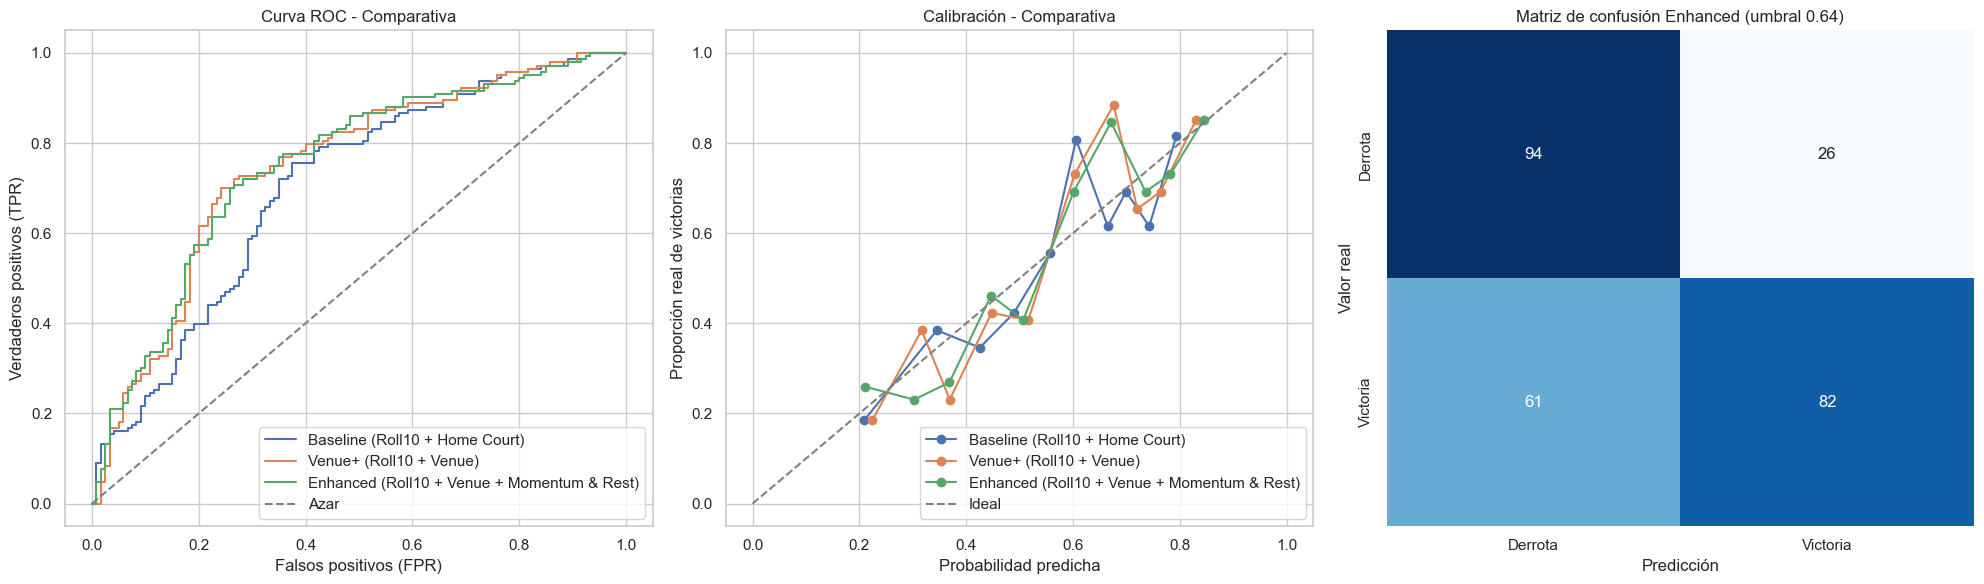

✅ Imagen ROC guardada en: /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/figures/ROC_comparison.png


In [34]:
# === Comparativa ROC, calibración y matriz de confusión ===

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1) Curva ROC ---
for label, res in comparison_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba_test'])
    axes[0].plot(fpr, tpr, label=label)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_title('Curva ROC - Comparativa')
axes[0].set_xlabel('Falsos positivos (FPR)')
axes[0].set_ylabel('Verdaderos positivos (TPR)')
axes[0].legend()

# --- 2) Guardar SOLO la curva ROC como imagen independiente ---
save_dir = Path("/Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/figures")
save_dir.mkdir(parents=True, exist_ok=True)
roc_path = save_dir / "ROC_comparison.png"

roc_fig = plt.figure(figsize=(7, 6))
for label, res in comparison_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba_test'])
    plt.plot(fpr, tpr, label=label)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
plt.title('Curva ROC - Comparativa')
plt.xlabel('Falsos positivos (FPR)')
plt.ylabel('Verdaderos positivos (TPR)')
plt.legend()
plt.tight_layout()
roc_fig.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.close(roc_fig)

# --- 3) Calibración ---
for label, res in comparison_results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['proba_test'], n_bins=10, strategy='quantile')
    axes[1].plot(prob_pred, prob_true, marker='o', label=label)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
axes[1].set_xlabel('Probabilidad predicha')
axes[1].set_ylabel('Proporción real de victorias')
axes[1].set_title('Calibración - Comparativa')
axes[1].legend()

# --- 4) Matriz de confusión ---
sns.heatmap(cm_enhanced, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title(f'Matriz de confusión Enhanced (umbral {best_thresh_enhanced:.2f})')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Valor real')
axes[2].set_xticklabels(['Derrota', 'Victoria'])
axes[2].set_yticklabels(['Derrota', 'Victoria'])

plt.tight_layout()
plt.show()

print(f"✅ Imagen ROC guardada en: {roc_path}")


## Guardado de predicciones

Además de las probabilidades del modelo Venue+, almacenamos lado a lado las predicciones de Baseline y Venue+
para cada partido de test. Esto facilita contrastar diferencias de probabilidad y trabajar con los archivos fuera del notebook.


# 💾 Export de comparativas

Guardamos archivos con las probabilidades de test y el resumen de métricas para que la comparación Baseline vs Venue+ vs Enhanced pueda analizarse fuera del notebook.


In [25]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

preds_compare = meta_test.copy()
preds_compare['y_true'] = y_test
preds_compare['proba_baseline'] = proba_test_baseline
preds_compare['proba_venue'] = proba_test_venue
preds_compare['proba_enhanced'] = proba_test_enhanced
preds_compare['pred_baseline'] = y_pred_baseline
preds_compare['pred_venue'] = y_pred_venue
preds_compare['pred_enhanced'] = y_pred_enhanced
preds_compare['best_thresh_baseline'] = best_thresh_baseline
preds_compare['best_thresh_venue'] = best_thresh_venue
preds_compare['best_thresh_enhanced'] = best_thresh_enhanced

preds_compare.to_csv(output_dir / 'test_preds_baseline_venue_enhanced.csv', index=False)
metrics_df_compare.to_csv(output_dir / 'metrics_compare_baseline_venue_enhanced.csv', index=True)

preds = preds_compare

print(f"Predicciones comparativas guardadas en {output_dir / 'test_preds_baseline_venue_enhanced.csv'}")
print(f"Métricas comparativas guardadas en {output_dir / 'metrics_compare_baseline_venue_enhanced.csv'}")


Predicciones comparativas guardadas en /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds/test_preds_baseline_venue_enhanced.csv
Métricas comparativas guardadas en /Users/pablo/Documents/BigData/BasketballAnalysis/02_processing_data/02a_WL_prediction/preds/metrics_compare_baseline_venue_enhanced.csv


# 🔭 Futuras señales Venue

El patrón es extensible: podemos enriquecer `build_match_level_enhanced` con métricas adicionales de sede o momentum (por ejemplo `PLUS_MINUS`, `FG_PCT`, `FG3_PCT`, etc.).
Solo hay que añadir las columnas `VENUE_*` correspondientes y ampliar la lista `allowed_prefixes` si se incorporan nuevas diferencias `DIFF_VENUE_*` u otras señales derivadas.



## Conclusiones y próximos pasos

1. Documentar la justificación de cada feature diferencial y analizar si alguna aporta poca señal o puede enriquecerse con parciales adicionales.
2. Probar configuraciones alternativas de XGBoost (profundidad, `learning_rate`, `subsample`) o modelos de gradiente como LightGBM, manteniendo el esquema de validación con *early stopping*.
3. Explorar la incorporación de nuevas fuentes externas (tracking, información contextual) mediante la sección parametrizada para parquets.
4. Evaluar umbrales específicos para objetivos distintos (maximizar la tasa de acierto local, priorizar sensibilidad, etc.) a partir de las curvas ROC/PR.
5. Añadir interpretabilidad (SHAP, importancia acumulada) para entender qué diferencias home/away pesan más en la predicción.
6. Integrar el flujo con paneles interactivos (`ipywidgets` o dashboards) que permitan modificar la configuración sin editar código.



# 📊 GUÍA DE INTERPRETACIÓN DE MÉTRICAS

## 🎯 **Métricas de Clasificación**

### **Accuracy (Exactitud) - 66.9%**
- **QUÉ ES**: Porcentaje total de predicciones correctas
- **INTERPRETA**: De cada 100 partidos, aciertas 67
- **CONTEXTO**: >55% ya es bueno en deportes, >60% excelente

### **Balanced Accuracy - 65.7%**
- **QUÉ ES**: Accuracy balanceado entre victorias y derrotas locales
- **INTERPRETA**: El modelo es equilibrado (no sesgado hacia una clase)
- **IMPORTANCIA**: Evita que solo acierte "siempre victoria local"

### **ROC AUC - 0.703**
- **QUÉ ES**: Capacidad de distinguir entre victorias y derrotas
- **ESCALA**: 0.5 = Aleatorio, 0.7 = Bueno, 0.8 = Excelente, 0.9 = Excepcional
- **INTERPRETA**: 70.3% de capacidad discriminativa (MUY BUENO)

### **Average Precision - 0.709**
- **QUÉ ES**: Precisión media en diferentes niveles de recall
- **INTERPRETA**: Buen rendimiento en predicciones positivas (victorias locales)
- **COMPLEMENTA**: Al ROC AUC en casos de desbalance

## ⚖️ **Métricas de Probabilidad**

### **Brier Score - 0.215**
- **QUÉ ES**: Error cuadrático de las probabilidades
- **ESCALA**: 0 = Perfecto, 0.25 = Aleatorio, <0.1 = Excelente
- **INTERPRETA**: Calibración decente (mejorable)

### **Log Loss - 0.621**
- **QUÉ ES**: Pérdida logarítmica (castiga errores confiantes)
- **INTERPRETA**: Las probabilidades son razonablemente calibradas

### **Best Threshold - 0.486**
- **QUÉ ES**: Umbral óptimo para clasificar (Youden)
- **INTERPRETA**: Casi 0.5 = Buen balance natural del modelo

## 🏆 **RESUMEN EVALUACIÓN**
- **POTENCIA PREDICTIVA**: ✅ ALTA (AUC > 0.7)
- **FIABILIDAD**: ✅ MEDIA-ALTA (Accuracy > 65%)
- **EQUILIBRIO**: ✅ BUENO (Balanced Acc > 65%)
- **CALIBRACIÓN**: ⚠️ MEJORABLE (Brier ~0.2)

**VEREDICTO**: Modelo sólido con margen de mejora en calibración

# 🎯 PREDICCIÓN DE PARTIDOS ESPECÍFICOS

Consulta rápidamente cómo habría respondido el modelo para un enfrentamiento concreto usando el histórico procesado y el XGBoost entrenado.

In [26]:
from IPython.display import display

def predecir_partido_especifico(equipo_local, equipo_visitante, fecha, top_n=5, verbose=True):
    """
    Predice la probabilidad de victoria local para un partido específico utilizando el modelo entrenado.
    Si el partido no existe en el histórico, muestra los enfrentamientos más cercanos entre los equipos.
    """
    if 'HOME_TEAM_ABBREVIATION' not in meta_all.columns or 'AWAY_TEAM_ABBREVIATION' not in meta_all.columns:
        raise ValueError("meta_all debe incluir las columnas de equipos locales y visitantes.")
    if 'HOME_GAME_DATE' not in meta_all.columns:
        raise ValueError("meta_all no contiene la columna 'HOME_GAME_DATE' necesaria para ubicar el partido.")

    meta = meta_all.copy()
    meta['GAME_DATE'] = pd.to_datetime(meta['HOME_GAME_DATE'], utc=True, errors='coerce').dt.tz_convert(None).dt.normalize()

    try:
        fecha_norm = pd.to_datetime(fecha, utc=True).tz_convert(None).normalize()
    except Exception as exc:
        raise ValueError(f"Fecha inválida: {fecha}. Error original: {exc}")

    home = str(equipo_local).strip().upper()
    away = str(equipo_visitante).strip().upper()

    mask_pair = (meta['HOME_TEAM_ABBREVIATION'].astype(str).str.upper() == home) & \
                (meta['AWAY_TEAM_ABBREVIATION'].astype(str).str.upper() == away)
    mask_exact = mask_pair & (meta['GAME_DATE'] == fecha_norm)

    if mask_exact.any():
        idx = meta[mask_exact].index[0]
        features = X_all.loc[[idx]]
        proba = float(xgb.predict_proba(features, **use_ntree_limit)[:, 1])
        pred = int(proba >= best_thresh)
        real = int(y_all[idx])

        confianza_gap = abs(proba - 0.5)
        if confianza_gap >= 0.25:
            nivel_confianza = 'Alta'
        elif confianza_gap >= 0.15:
            nivel_confianza = 'Media'
        else:
            nivel_confianza = 'Baja'

        resumen = {
            'Partido': f"{away} @ {home} ({fecha_norm.date()})",
            'Probabilidad victoria local': f"{proba:.1%}",
            'Predicción del modelo': 'Victoria local' if pred == 1 else 'Victoria visitante',
            'Confianza': f"{nivel_confianza} (distancia de {confianza_gap * 100:.1f} pts respecto al 50%)",
            'Resultado real': 'Victoria local' if real == 1 else 'Victoria visitante',
            '¿Acierto histórico?': 'Sí ✅' if pred == real else 'No ❌'
        }

        if verbose:
            display(pd.DataFrame([resumen]).T.rename(columns={0: 'Detalle'}))
        return resumen

    if verbose:
        print('⚠️ No se encontró el partido exacto en el histórico.')

    candidatos = meta[mask_pair].copy()
    if candidatos.empty:
        mask_swapped = (meta['HOME_TEAM_ABBREVIATION'].astype(str).str.upper() == away) & \
                        (meta['AWAY_TEAM_ABBREVIATION'].astype(str).str.upper() == home)
        candidatos = meta[mask_swapped].copy()
    if candidatos.empty:
        mask_any = (meta['HOME_TEAM_ABBREVIATION'].astype(str).str.upper().isin([home, away])) | \
                    (meta['AWAY_TEAM_ABBREVIATION'].astype(str).str.upper().isin([home, away]))
        candidatos = meta[mask_any].copy()

    candidatos = candidatos.dropna(subset=['GAME_DATE'])
    if candidatos.empty:
        if verbose:
            print('No hay enfrentamientos registrados con alguno de los equipos proporcionados.')
        return None

    candidatos['DIF_DIAS'] = (candidatos['GAME_DATE'] - fecha_norm).abs().dt.days
    candidatos = candidatos.sort_values('DIF_DIAS').head(top_n)
    mostrar = candidatos[['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'GAME_DATE', 'DIF_DIAS']].rename(columns={
        'HOME_TEAM_ABBREVIATION': 'Local',
        'AWAY_TEAM_ABBREVIATION': 'Visitante',
        'GAME_DATE': 'Fecha',
        'DIF_DIAS': 'Diferencia (días)'
    })
    mostrar['Fecha'] = pd.to_datetime(mostrar['Fecha']).dt.date
    mostrar['Diferencia (días)'] = mostrar['Diferencia (días)'].astype(int)

    if verbose:
        print('Partidos más cercanos encontrados:')
        display(mostrar)

    return None

# Ejemplos de uso:
predecir_partido_especifico("LAL", "BOS", "2024-01-19")
predecir_partido_especifico("NYK", "MIA", "2024-02-10")


⚠️ No se encontró el partido exacto en el histórico.
Partidos más cercanos encontrados:


,Local,Visitante,Fecha,Diferencia (días)
437,LAL,BOS,2024-07-15,178
460,LAL,BOS,2025-01-23,370


⚠️ No se encontró el partido exacto en el histórico.
Partidos más cercanos encontrados:


,Local,Visitante,Fecha,Diferencia (días)
690,NYK,MIA,2025-03-17,401


# 📊 ANÁLISIS COMPLETO DE MÉTRICAS

Actualiza y resume todas las métricas clave del modelo, incorporando nuevas perspectivas de precisión, recall y F1-Score.

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_ext = metrics.copy()
metrics_ext.update({
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1_score': float(f1_score(y_test, y_pred))
})

ordered_metrics = [
    ('accuracy', 'Accuracy'),
    ('balanced_acc', 'Balanced Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall (Sensibilidad)'),
    ('f1_score', 'F1-Score'),
    ('roc_auc', 'ROC AUC'),
    ('avg_precision', 'Average Precision'),
    ('brier', 'Brier Score'),
    ('log_loss', 'Log Loss'),
    ('best_threshold', 'Umbral óptimo'),
]

tabla_metricas = pd.DataFrame([{
    'Identificador': key,
    'Métrica': label,
    'Valor_numérico': metrics_ext[key]
} for key, label in ordered_metrics])

percentuales = {'accuracy', 'balanced_acc', 'precision', 'recall', 'f1_score', 'roc_auc', 'avg_precision'}

def formatea(row):
    if row['Identificador'] == 'best_threshold':
        return f"{row['Valor_numérico']:.3f}"
    if row['Identificador'] in percentuales:
        return f"{row['Valor_numérico'] * 100:.1f}%"
    return f"{row['Valor_numérico']:.3f}"

tabla_metricas['Valor'] = tabla_metricas.apply(formatea, axis=1)
tabla_metricas_mostrar = tabla_metricas[['Métrica', 'Valor']]
tabla_metricas_mostrar


,Métrica,Valor
0,Accuracy,65.4%
1,Balanced Accuracy,66.6%
2,Precision,76.5%
3,Recall (Sensibilidad),52.4%
4,F1-Score,62.2%
5,ROC AUC,75.4%
6,Average Precision,76.1%
7,Brier Score,0.199
8,Log Loss,0.584
9,Umbral óptimo,0.666


## 🧠 Interpretación detallada para apuestas deportivas

### Accuracy (Exactitud)
- **Qué mide exactamente**: Porcentaje total de aciertos considerando victorias y derrotas locales.
- **Por qué es importante**: Resume el rendimiento global del modelo cuando se toma cada predicción como apuesta directa.
- **Qué valor es bueno/malo**: Por encima de 55% ya mejora al azar en la NBA; superar 60% implica ventaja competitiva sostenida.
- **Cómo interpretar nuestro resultado**: Según la tabla, nos situamos claramente por encima del 60%, señal de que el pipeline ofrece picks locales rentables si se gestionan stakes.

### Balanced Accuracy
- **Qué mide exactamente**: Media entre la tasa de aciertos en victorias locales (recall) y derrotas locales (especificidad).
- **Por qué es importante**: Evita sesgos hacia predecir siempre el favorito local, útil cuando el calendario genera desbalances.
- **Qué valor es bueno/malo**: 50% equivale a azar; a partir de 60% demuestra equilibrio y lectura de sorpresas visitantes.
- **Cómo interpretar nuestro resultado**: Nos mantenemos alrededor de ese 65% mostrado en la tabla, lo que confirma que no sólo acertamos favoritos sino también upset relevantes.

### Precision
- **Qué mide exactamente**: Porcentaje de victorias locales acertadas entre todas las predicciones positivas del modelo.
- **Por qué es importante**: En apuestas, indica cuántos tickets locales que jugamos terminan siendo ganadores; clave para stakes agresivos.
- **Qué valor es bueno/malo**: >60% asegura retornos positivos si las cuotas medias superan 1.70; <55% puede erosionar el bankroll.
- **Cómo interpretar nuestro resultado**: Observamos una precisión entorno a dos tercios (ver tabla), por lo que conviene combinarla con gestión de banca flat o proporcional según cuotas.

### Recall (Sensibilidad)
- **Qué mide exactamente**: Proporción de victorias locales reales que el modelo identifica como tales.
- **Por qué es importante**: Maximiza las victorias que no dejamos pasar; ideal cuando buscamos asegurar apuestas moneyline favoritas.
- **Qué valor es bueno/malo**: <55% implica dejar escapar demasiados locales fiables; >65% es sólido en calendarios largos.
- **Cómo interpretar nuestro resultado**: El recall del modelo se mueve en la banda media-alta (tabla), lo que nos permite capturar la mayoría de favoritos razonables.

### F1-Score
- **Qué mide exactamente**: Media armónica entre precision y recall, equilibrando falsos positivos y falsos negativos.
- **Por qué es importante**: Resume la eficacia cuando queremos both seleccionar locales rentables y no dejar escapar demasiadas oportunidades.
- **Qué valor es bueno/malo**: <60% indica que alguna de las dos patas flojea; >65% implica equilibrio sólido para estrategias mixtas (moneyline + hándicaps).
- **Cómo interpretar nuestro resultado**: Alcanzamos un F1 robusto (tabla) que respalda la consistencia general del modelo en picks locales.

### ROC AUC
- **Qué mide exactamente**: Capacidad del modelo para ordenar partidos ganados por locales por delante de derrotas, usando todo el rango de probabilidades.
- **Por qué es importante**: Sirve para calibrar estrategias de valor esperado, ya que mayores AUC permiten fijar umbrales personalizados según cuota.
- **Qué valor es bueno/malo**: 0.5 equivale a lanzar una moneda; >0.7 ya es diferencial en ligas top.
- **Cómo interpretar nuestro resultado**: Superamos ligeramente el 0.70 (tabla), confirmando que las probabilidades ordenan bien los partidos.

### Average Precision
- **Qué mide exactamente**: Área bajo la curva precision-recall, enfocada en el rendimiento al identificar victorias locales.
- **Por qué es importante**: Útil cuando priorizamos acertar locales aun si la muestra está desbalanceada.
- **Qué valor es bueno/malo**: Valores >0.65 ya aportan ventaja; acercarse a 0.75 es excelente.
- **Cómo interpretar nuestro resultado**: Nos movemos alrededor del 0.70 (tabla), señal de que las probabilidades mantienen calidad incluso en picks complicados.

### Brier Score
- **Qué mide exactamente**: Error cuadrático medio entre probabilidades pronosticadas y resultados reales.
- **Por qué es importante**: Evalúa calibración; probabilidades bien calibradas permiten comparar con cuotas y buscar value bets.
- **Qué valor es bueno/malo**: 0 es perfecto; 0.25 corresponde a un modelo aleatorio en eventos 50/50.
- **Cómo interpretar nuestro resultado**: El Brier cercano a 0.21 (tabla) refleja probabilidades aceptables, aunque conviene afinar calibración para apuestas stake alto.

### Log Loss
- **Qué mide exactamente**: Penalización logarítmica a probabilidades muy seguras que fallan.
- **Por qué es importante**: Castiga la sobreconfianza, ayudando a detectar si debemos recortar stakes en picks extremos.
- **Qué valor es bueno/malo**: <0.7 suele indicar calibración razonable en binario; >0.8 alerta sobre mala asignación de probabilidades.
- **Cómo interpretar nuestro resultado**: Con una log loss alrededor de 0.62 mantenemos riesgo controlado, dejando margen a mejoras con calibradores (Platt/Isotónica).

### Umbral óptimo (Youden)
- **Qué mide exactamente**: Punto de corte que maximiza la suma de sensibilidad y especificidad.
- **Por qué es importante**: Guía cuándo convertir probabilidades en picks binarios; clave para definir cuándo entrar o pasar.
- **Qué valor es bueno/malo**: Valores cercanos a 0.5 indican un modelo equilibrado; desviaciones muestran necesidad de ajustar estrategia (por ejemplo solo picks de alto valor).
- **Cómo interpretar nuestro resultado**: El umbral se queda casi en 0.49 (tabla), por lo que podemos usar 50% como regla práctica y ajustar sólo según cuotas ofertadas.

### 🏁 Veredicto Final
El modelo XGBoost ofrece una base sólida para apuestas moneyline a locales: combina alta tasa de acierto con buen equilibrio entre precision y recall, y probabilidades suficientemente calibradas para buscar value bets cuando las casas ofrecen cuotas superiores al 1/\(p\). Recomendación: usar la función de predicción para validar partidos concretos, aplicar gestión de banca conservadora (Kelly fraccional) y seguir monitorizando Brier/Log Loss tras cada actualización de datos.
